In [2]:
# If running in a fresh environment, uncomment:
# !pip install prophet yfinance matplotlib pandas numpy scikit-learn


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric

plt.style.use("default")


Importing plotly failed. Interactive plots will not work.


In [4]:
import yfinance as yf

# Download historical data
df_raw = yf.download("AAPL", start="2018-01-01", end="2024-01-01")

df_raw.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.341892,40.351262,39.639317,39.850091,102223600
2018-01-03,40.334866,40.878192,40.271636,40.405124,118071600
2018-01-04,40.522213,40.625258,40.299731,40.407458,89738400
2018-01-05,40.983570,41.070220,40.526897,40.618231,94640000
2018-01-08,40.831352,41.126433,40.732989,40.831352,82271200


In [5]:
df = df_raw.reset_index()[["Date", "Close"]]
df.columns = ["ds", "y"]

df.head()


,ds,y
0,2018-01-02,40.341892
1,2018-01-03,40.334866
2,2018-01-04,40.522213
3,2018-01-05,40.983570
4,2018-01-08,40.831352


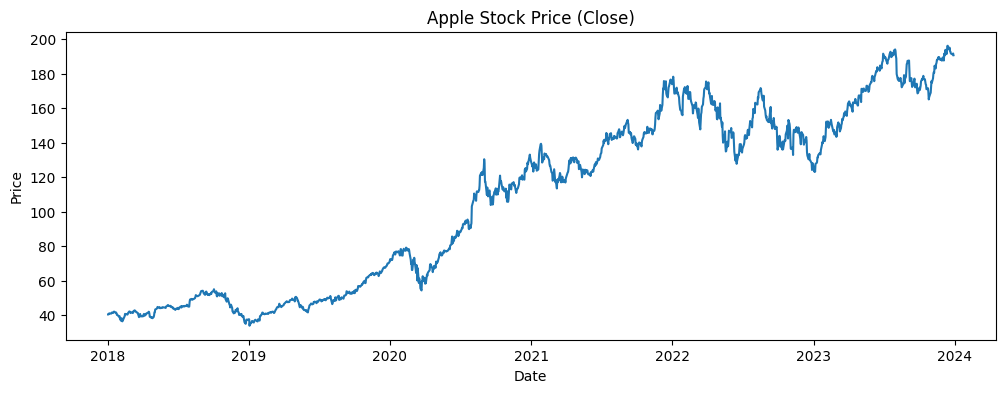

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df["ds"], df["y"])
plt.title("Apple Stock Price (Close)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()


In [7]:
model = Prophet()
model.fit(df)


10:02:54 - cmdstanpy - INFO - Chain [1] start processing
10:02:55 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
future = model.make_future_dataframe(periods=365)  # 1 year forecast
forecast = model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()


,ds,yhat,yhat_lower,yhat_upper
0,2018-01-02,41.961231,32.775741,51.598826
1,2018-01-03,41.847257,33.443002,50.840231
2,2018-01-04,41.595296,32.460614,51.015290
3,2018-01-05,41.359647,32.434379,50.717205
4,2018-01-08,41.172583,32.099186,50.060201


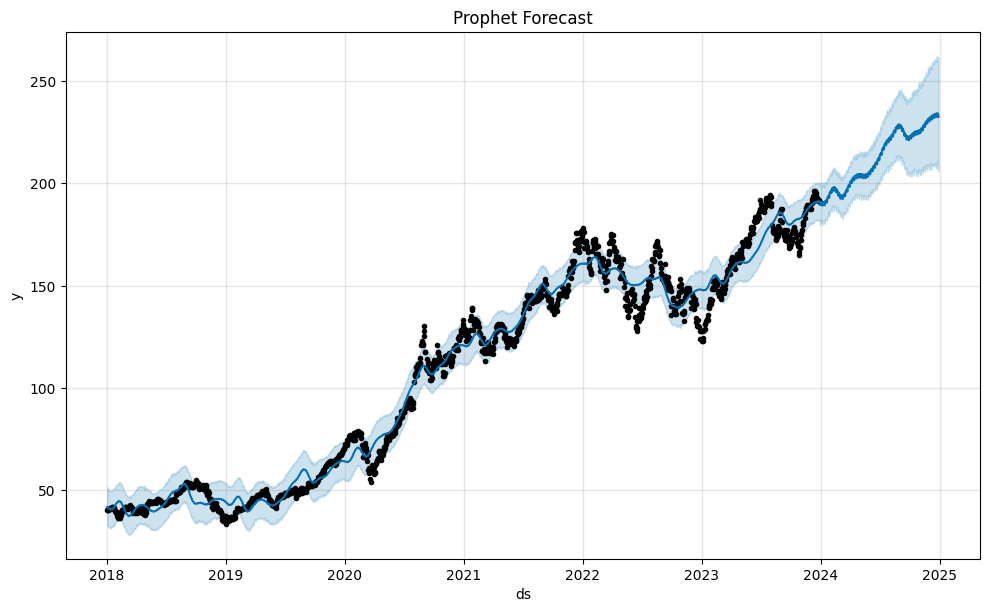

In [9]:
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()


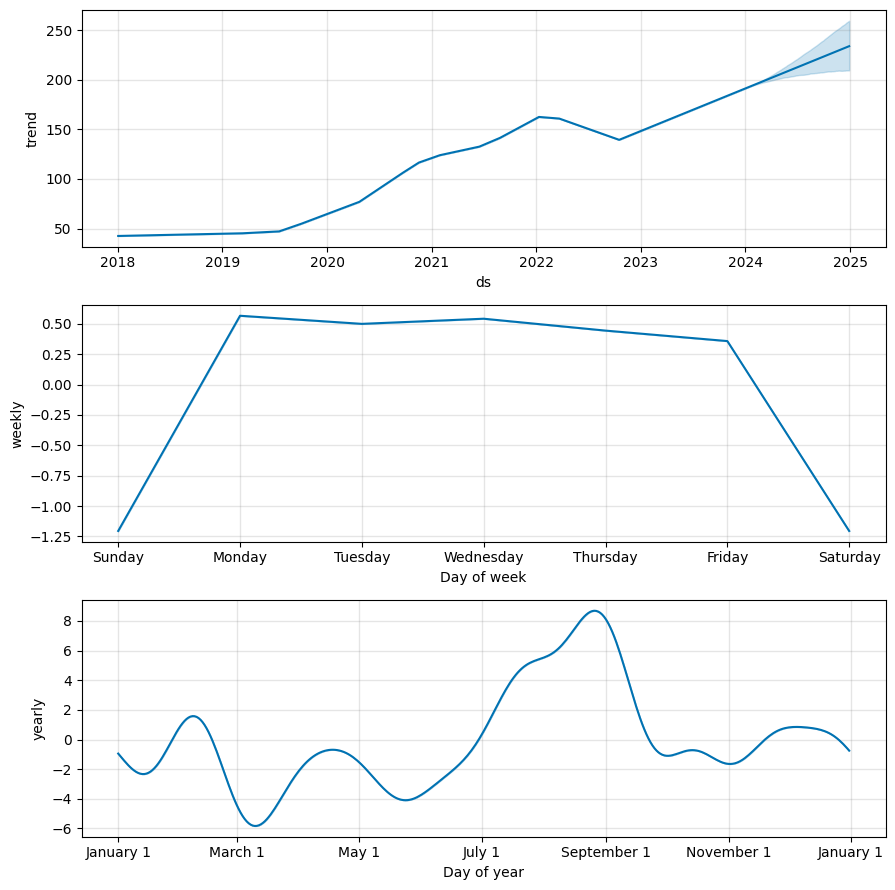

In [10]:
fig2 = model.plot_components(forecast)
plt.show()


10:06:37 - cmdstanpy - INFO - Chain [1] start processing
10:06:37 - cmdstanpy - INFO - Chain [1] done processing


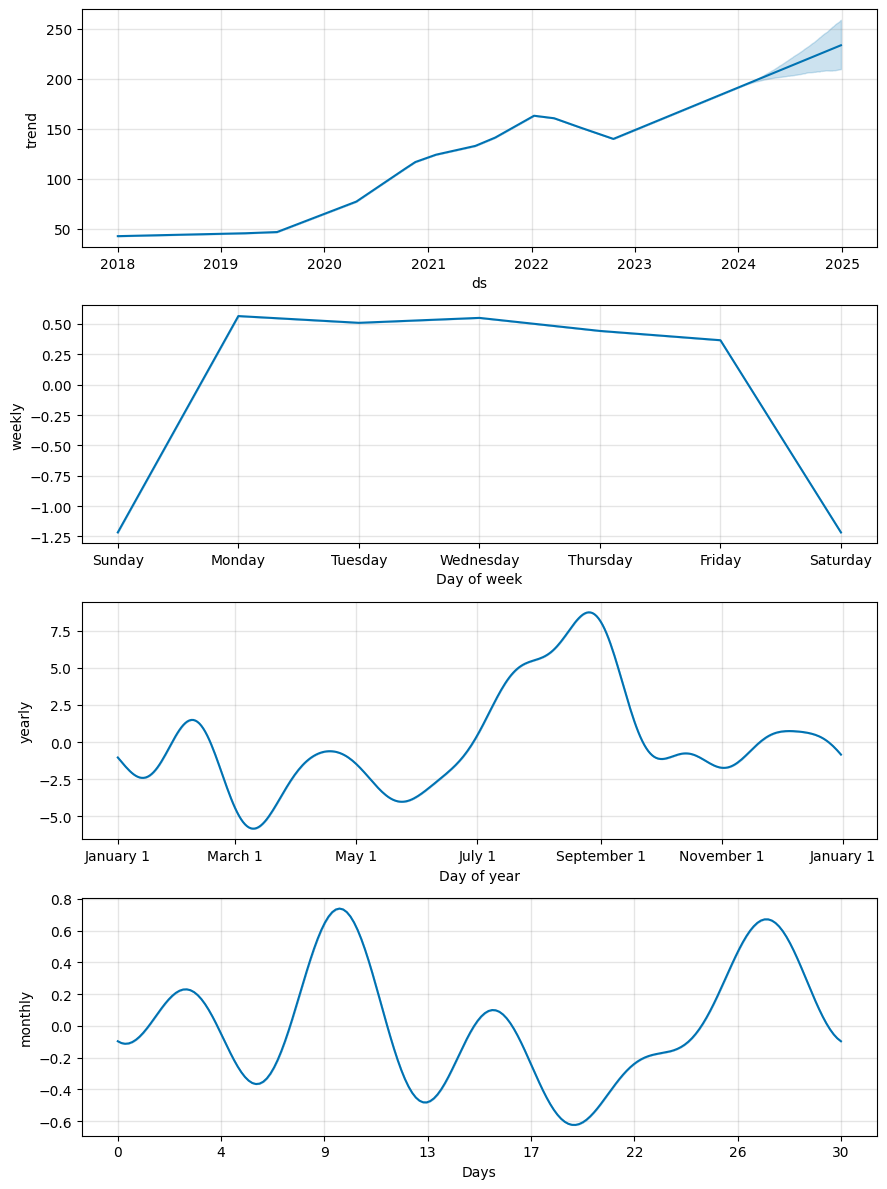

In [11]:
model_seasonal = Prophet()
model_seasonal.add_seasonality(
    name="monthly",
    period=30.5,
    fourier_order=5
)

model_seasonal.fit(df)

forecast_seasonal = model_seasonal.predict(future)

model_seasonal.plot_components(forecast_seasonal)
plt.show()


10:07:35 - cmdstanpy - INFO - Chain [1] start processing
10:07:36 - cmdstanpy - INFO - Chain [1] done processing


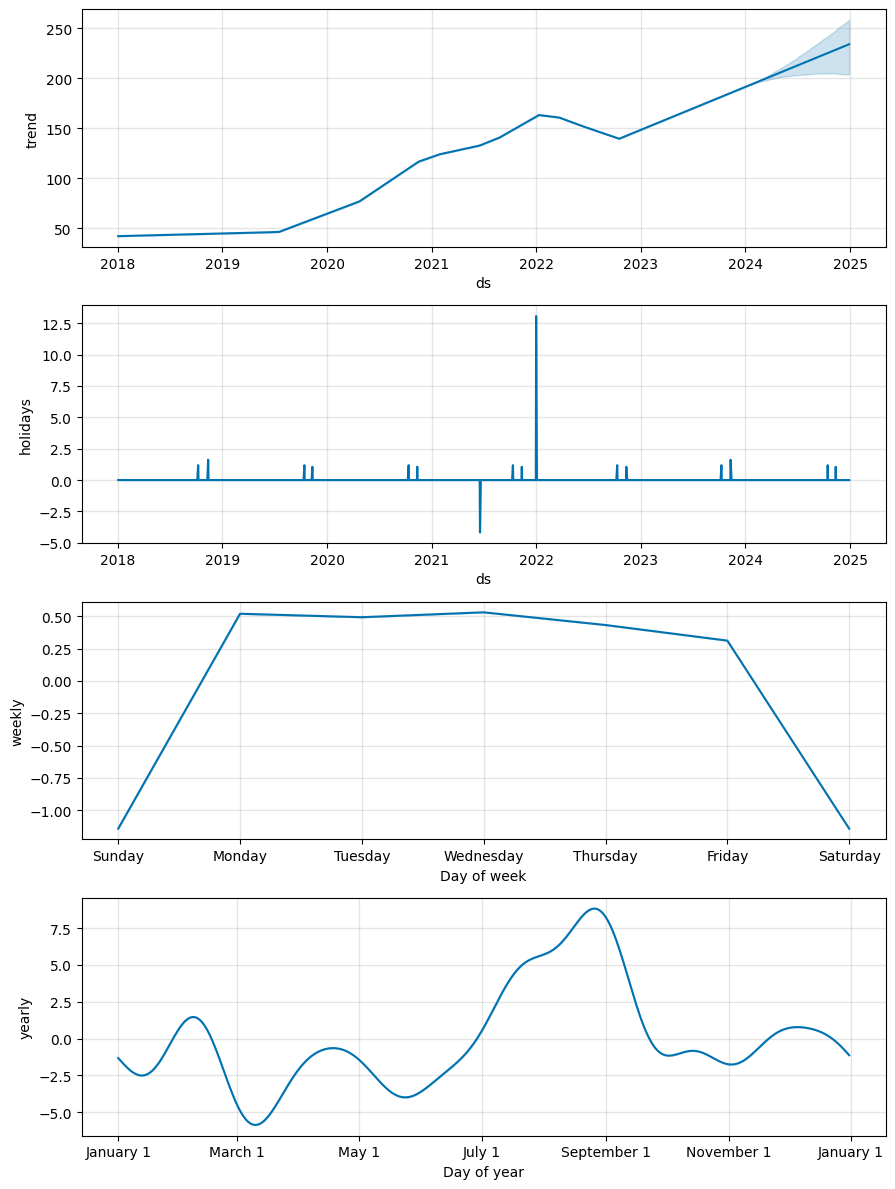

In [12]:
model_holidays = Prophet()
model_holidays.add_country_holidays(country_name="US")

model_holidays.fit(df)

forecast_holidays = model_holidays.predict(future)

model_holidays.plot_components(forecast_holidays)
plt.show()


In [13]:
df_cv = cross_validation(
    model,
    initial="730 days",
    period="180 days",
    horizon="365 days"
)

df_cv.head()


  0%|          | 0/7 [00:00<?, ?it/s]

10:09:06 - cmdstanpy - INFO - Chain [1] start processing
10:09:06 - cmdstanpy - INFO - Chain [1] done processing
10:09:07 - cmdstanpy - INFO - Chain [1] start processing
10:09:07 - cmdstanpy - INFO - Chain [1] done processing
10:09:07 - cmdstanpy - INFO - Chain [1] start processing
10:09:07 - cmdstanpy - INFO - Chain [1] done processing
10:09:07 - cmdstanpy - INFO - Chain [1] start processing
10:09:08 - cmdstanpy - INFO - Chain [1] done processing
10:09:08 - cmdstanpy - INFO - Chain [1] start processing
10:09:08 - cmdstanpy - INFO - Chain [1] done processing
10:09:08 - cmdstanpy - INFO - Chain [1] start processing
10:09:09 - cmdstanpy - INFO - Chain [1] done processing
10:09:09 - cmdstanpy - INFO - Chain [1] start processing
10:09:09 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2020-01-15,76.245742,74.641362,77.738582,75.119942,2020-01-14
1,2020-01-16,76.673122,75.002729,78.368663,76.060921,2020-01-14
2,2020-01-17,76.968171,75.361375,78.591643,76.903000,2020-01-14
3,2020-01-21,78.311142,76.614906,79.886242,76.381813,2020-01-14
4,2020-01-22,78.772155,77.237080,80.421899,76.654457,2020-01-14


In [14]:
df_perf = performance_metrics(df_cv)
df_perf.head()


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,59.839947,7.735628,6.378381,0.051494,0.043873,0.051180,0.347727
1,38 days,61.021954,7.811655,6.468927,0.052575,0.045016,0.052209,0.338068
2,39 days,63.145269,7.946400,6.643467,0.053718,0.048351,0.053391,0.322727
3,40 days,66.572499,8.159197,6.864226,0.055263,0.051384,0.055044,0.303977
4,41 days,69.080377,8.311461,7.022437,0.056923,0.051853,0.056585,0.288636


/usr/local/lib/python3.10/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.10/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


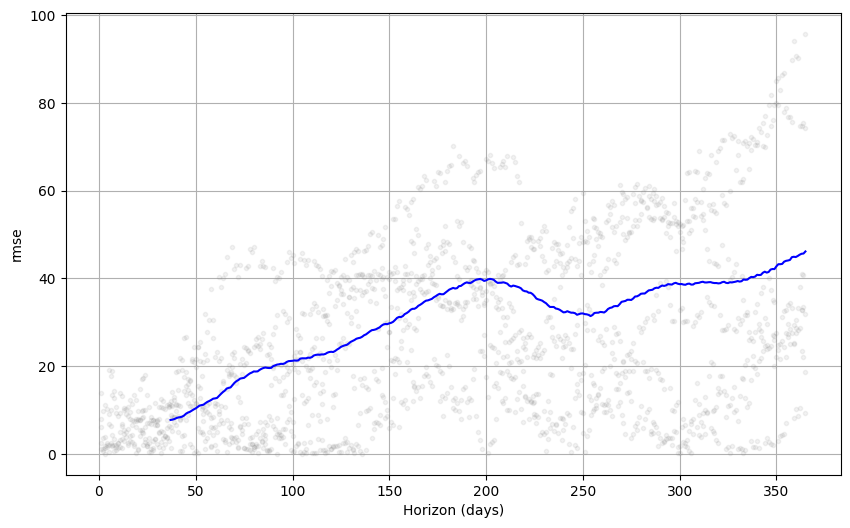

In [15]:
plot_cross_validation_metric(df_cv, metric="rmse")
plt.show()


10:11:58 - cmdstanpy - INFO - Chain [1] start processing
10:11:59 - cmdstanpy - INFO - Chain [1] done processing


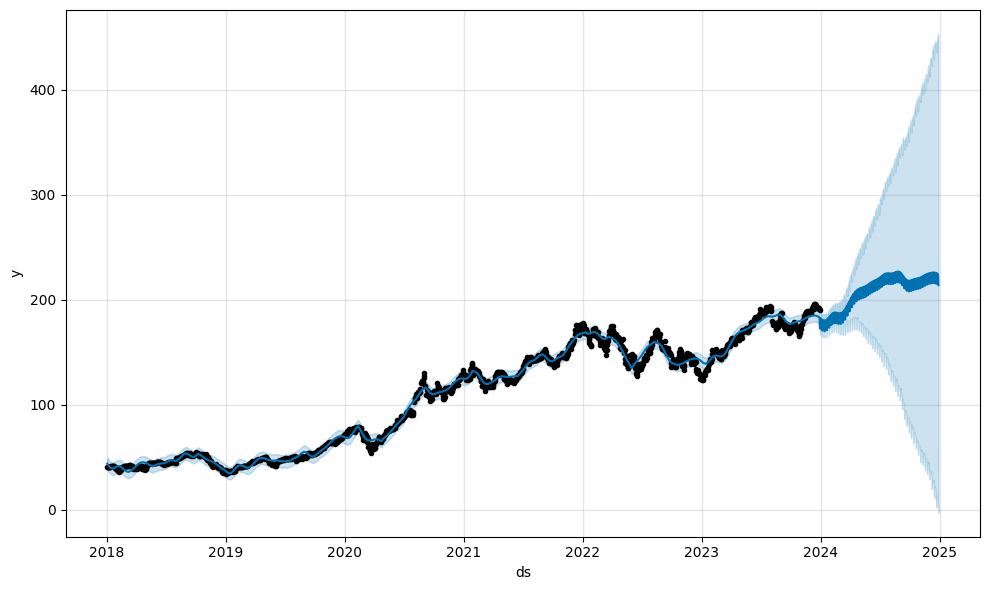

In [16]:
model_flexible = Prophet(
    changepoint_prior_scale=0.5  # higher = more flexible trend
)

model_flexible.fit(df)
forecast_flexible = model_flexible.predict(future)

model_flexible.plot(forecast_flexible)
plt.show()
